# Supplementary Fig. 7 — error-corrected sequencing metrics (SNV/indel panel)

Quality metrics of the TETRIS-seq duplex-UMI error-corrected sequencing across all longitudinal pre-AML
and control samples on the SNV/indel panel:

- **a** — distribution of **peak** UMI tag family sizes (SSCS) across samples, with example family-size
  distributions for peaks of 2, 5 and 10 (insets).
- **b** — distribution of **mean** UMI tag family sizes (pre-AMLs red, controls blue), with the standard
  deviation of each sample's family-size distribution (inset).
- **c** — distribution of the **proportion of total reads retained** if UMI families with < 3 reads are discarded.
- **d** — distribution of the **proportion of UMI families retained** under the same minimum-family-size-3 rule.
- **e** — distribution of the **SSCS:DCS ratio**.

## Data availability

This notebook uses **aggregate sequencing QC metrics** — UMI family-size counts and SSCS/DCS consensus
counts, plus a plain list of sample IDs.

| path | contents | location |
|---|---|---|
| `/Supp Fig. 7 - Error corrected sequencing metrics/Metrics_UMI_and_N/SNV_panel/SLX_*/…_SSCS_UMI_metrics_MUFS3.txt` | per-sample UMI tag family-size distributions | Data_files |
| `/Supp Fig. 7 - Error corrected sequencing metrics/SSCS_to_DCS_ratio_metrics/SLX_*/…_DCS_metrics.txt` | per-sample SSCS/DCS consensus counts | Data_files |
| `/Supp Fig. 7 - Error corrected sequencing metrics/Supp_Fig_7_included_samples.csv` | the 249 pre-AML + 247 control included timepoint IDs (sample IDs only) | Data_files |

## 1. Imports

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import csv

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Helvetica']

## 2. Colours

In [2]:
# Lists of colors for plots
c0 = (0.76, 0.76, 0.76)
c1 = (1.00, 0.18, 0.33);
c2 = (1.00, 0.23, 0.19);
c3 = (1.00, 0.58, 0.00);
c4 = (1.00, 0.80, 0.00);
c5 = (0.30, 0.85, 0.39);
c6 = (0.35, 0.78, 0.98);
c7 = (0.20, 0.67, 0.86);
c8 = (0.00, 0.48, 1.00);
c9 = (0.35, 0.34, 0.84);
c10 = (0.00, 0.31, 0.57);
c11 = (0.12, 0.29, 0.69);
c12 = (0.17, 0.17, 0.42);
c13 = (1.00, 1.00, 1.00);
c14 = (0.77, 0.04, 0.00);

In [3]:
#define the colors from colorbrewer2
orange1 = '#feedde'
orange2 = '#fdbe85'
orange3 = '#fd8d3c'
orange4 = '#e6550d'
orange5 = '#a63603'
blue1 = '#eff3ff'
blue2 = '#bdd7e7'
blue3 = '#6baed6'
blue4 = '#3182bd'
blue5 = '#08519c'
green1 = '#edf8e9'
green2 = '#bae4b3'
green3 = '#74c476'
green4 = '#31a354'
green5 = '#006d2c'
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'
purple1 = '#f2f0f7'
purple2 = '#cbc9e2'
purple3 = '#9e9ac8'
purple4 = '#756bb1'
purple5 = '#54278f'
red1 = '#fee5d9'
red2 = '#fcae91'
red3 = '#fb6a4a'
red4 = '#de2d26'
red5 = '#a50f15'

## 3. Enumerate samples and build metric-file lists

In [ ]:
cases_and_controls = {}
with open('Data_files/Supp Fig. 7 - Error corrected sequencing metrics/Supp_Fig_7_included_samples.csv') as csvfile:
    readreader = csv.reader(csvfile)
    row_count = 0
    for row in readreader:
        if row_count > 0:                       # skip the 'sample_id' header
            timepoint = row[0]
            sample_name = timepoint.split('_')[0] + '_' + timepoint.split('_')[1]
            cases_and_controls.setdefault(sample_name, []).append(timepoint)
        row_count += 1

# sort each patient's timepoints by timepoint number (…_sN)
cases_and_controls_sorted = {}
for k, v in cases_and_controls.items():
    cases_and_controls_sorted[k] = sorted(v, key=lambda t: int(t.split('_')[2][1:]))

In [5]:
#sequencing libraries
libraries = ['SLX_19284', 'SLX_20124', 'SLX_20126', 'SLX_20128', 'SLX_20200', 'SLX_20202', 'SLX_20374', 'SLX_20375', 'SLX_20376', 'SLX_20377', 'SLX_20378', 'SLX_20546', 'SLX_20547', 'SLX_20548']

In [6]:
#Filenames for each timepoint for each sample (sampleS)...
n = 0
sample_filenames = {}
timepoints_available = {}
cases = []
controls = []

for sample in cases_and_controls_sorted.keys():
    filenames = []
    timepoints = cases_and_controls_sorted[sample]
    for time in timepoints:
        for library in libraries:
            filename = 'Data_files/Supp Fig. 7 - Error corrected sequencing metrics/Metrics_UMI_and_N/SNV_panel/'+library+'/'+time+'_SNV_watson_code_SSCS_UMI_metrics_MUFS3.txt'
            filename2 = 'Data_files/Supp Fig. 7 - Error corrected sequencing metrics/Metrics_UMI_and_N/SNV_panel/'+library+'/'+time+'_watson_code_SSCS_UMI_metrics_MUFS3.txt'
            if os.path.isfile(filename):
                sample_filenames[time]=filename
                if 'C92' in sample:
                    if sample not in cases:
                        cases.append(sample)
                else:
                    if sample not in controls:
                        controls.append(sample)
            if os.path.isfile(filename2):
                sample_filenames[time]=filename2
                if 'C92' in sample:
                    if sample not in cases:
                        cases.append(sample)
                else:
                    if sample not in controls:
                        controls.append(sample)
        
    n+=1


In [7]:
# mean UMI family size across all samples
n = 0

sample_mean_family_size = {}

for k, v in sample_filenames.items():
    sample_name = k
    file = v

    if 'SNV' in os.path.basename(file):
        name = os.path.basename(file).split('SNV')[0][:-1]
    else:
        name = os.path.basename(file).split('watson')[0][:-1]

    UMI_family_sizes = {}
    total_reads = 0
    total_count = 0

    m = 0
    
    #calculate mean
    with open(file) as txtfile:
        row_count = 0
        reader = csv.reader(txtfile, delimiter = '\t')
        for row in reader:
            if row_count>15:
#                 print(row)
                UMI_family_size = int(row[0])
                count = float(row[1])
                fraction = row[2]
                reads = UMI_family_size*count 
                total_reads += reads
                total_count += count
            row_count+=1

        mean_UMI_family_size = total_reads/total_count
        
    #calculate standard deviation
    
    with open(file) as txtfile:
        #calculate mean
        total_square_distance = 0
    
        row_count = 0
        reader = csv.reader(txtfile, delimiter = '\t')
        for row in reader:
#             print(row)
            if row_count>15:
                UMI_family_size = int(row[0])
                count = float(row[1])
                fraction = row[2]
                reads = UMI_family_size*count 
                square_distance = count*((UMI_family_size-mean_UMI_family_size)**2)
                total_square_distance+=square_distance
            row_count+=1
        
        standard_deviation = np.sqrt(total_square_distance/total_count)

        sample_mean_family_size[name]=(mean_UMI_family_size, standard_deviation)

### Supplementary Fig. 7a - Distribution of peak UMI tag family sizes

In [8]:
# Mode UMI family size (excluding peak at 1)
n = 0

mode_family_size = {}

for k, v in sample_filenames.items():
    sample_name = k
    file = v

    if 'SNV' in os.path.basename(file):
        name = os.path.basename(file).split('SNV')[0][:-1]
    else:
        name = os.path.basename(file).split('watson')[0][:-1]

    UMI_family_sizes = {}
    total_reads = 0
    total_count = 0

    m = 0
    
    family_size_counts = []
    family_size_dict = {}
    
    #calculate mode
    with open(file) as txtfile:
        row_count = 0
        reader = csv.reader(txtfile, delimiter = '\t')
        for row in reader:
            if row_count>15:
#                 print(row)
                UMI_family_size = int(row[0])
                count = float(row[1])
                fraction = row[2]
                reads = UMI_family_size*count 
                total_reads += reads
                total_count += count
                family_size_dict[UMI_family_size]=count
                if UMI_family_size != 1:
                    family_size_counts.append(count)
            row_count+=1

        max_count = max(family_size_counts)
        
        for a, b in family_size_dict.items():
            if b == max_count:
                mode_size = a
                
        mode_family_size[k]=mode_size

n= 0 
for k, v in mode_family_size.items():
    if v == 2:
        n+=1


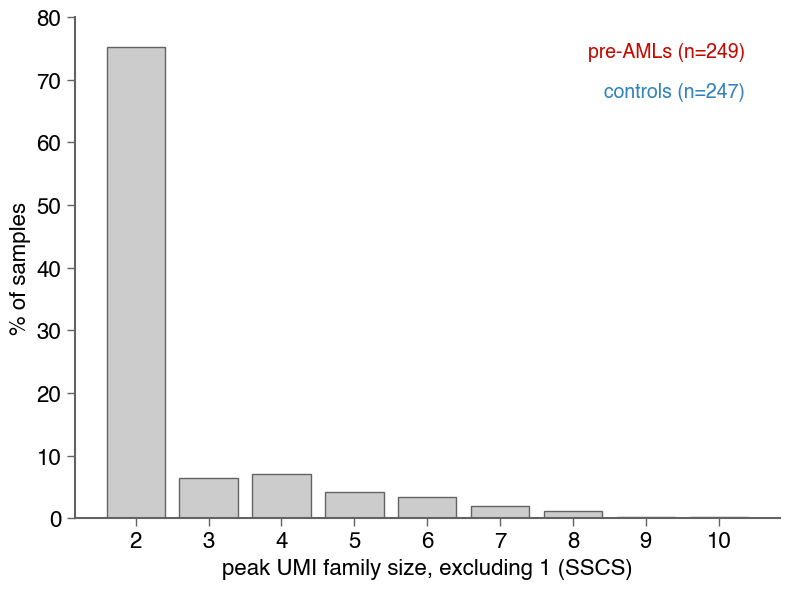

In [9]:
#Mode UMI family size across all samples
fig, ax1 = plt.subplots(1, 1, figsize = (8, 6))

mode_family_sizes_cases = {}
mode_family_sizes_controls = {}
mode_family_sizes_all = {}

for k, v in mode_family_size.items():
#     print(k)
    if 'C92' in k:
        if v in mode_family_sizes_cases.keys():
            mode_family_sizes_cases[v]+=1
        else:
            mode_family_sizes_cases[v]=1
    if 'CNTRL' in k:
        if v in mode_family_sizes_controls.keys():
            mode_family_sizes_controls[v]+=1
        else:
            mode_family_sizes_controls[v]=1
    if v in mode_family_sizes_all.keys():
        mode_family_sizes_all[v]+=1
    else:
        mode_family_sizes_all[v]=1
        
x = []
y = []

total_samples = 0
for k, v in mode_family_sizes_all.items():
    total_samples+=v
    
for k, v in mode_family_sizes_all.items():
    x.append(k)
    y.append((v/total_samples)*100)
    
ax1.bar(x, y, color = grey2, edgecolor = grey4)
    
for ax in [ax1]:
#     ax.set_xlim(0, 51)
    ax.set_ylim(0, 80)
    ax.set_xlabel('peak UMI family size, excluding 1 (SSCS)', fontsize = 16)
    ax.set_ylabel('% of samples', fontsize = 16)
    ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 16)
    ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
    for axis in ['right', 'top']:
        ax.spines[axis].set_visible(False)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey4)
        
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    
ax1.text(0.95, 0.92, 'pre-AMLs (n='+str(sum(mode_family_sizes_cases.values()))+')', transform=ax1.transAxes, ha='right', fontsize=14, color=c14)
ax1.text(0.95, 0.84, 'controls (n='+str(sum(mode_family_sizes_controls.values()))+')', transform=ax1.transAxes, ha='right', fontsize=14, color=blue4)
        
plt.tight_layout()

### Supplementary Fig. 7a subplots - Example distributions (peak UMI family size 2, 5, 10)

In [10]:
mode2_samples = []
mode10_samples = []
mode5_samples = []

for k, v in mode_family_size.items():
    mode = v
    if mode == 2:
        mean = sample_mean_family_size[k][0]
        std = sample_mean_family_size[k][1]
        if (7.5 < mean < 8.5) and (9.5 < std < 10.5):
            mode2_samples.append(k)
    if mode == 5:
        mode5_samples.append(k)
    if mode == 10:
        mode10_samples.append(k)

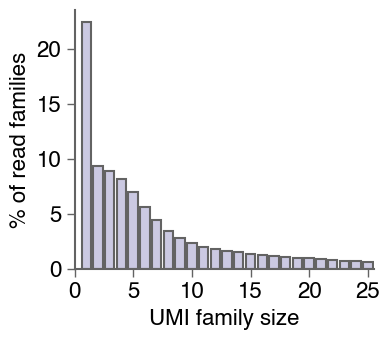

In [11]:
for sample in sorted(mode2_samples)[:1]:
    file = sample_filenames[sample]
    
    fig, ax1 = plt.subplots(1, 1, figsize = (4, 3.5))
    
    x = []
    y = []
    
    with open(file) as txtfile:
        row_count = 0
        reader = csv.reader(txtfile, delimiter = '\t')
        
        for row in reader:
            if row_count>15:
#                 print(row)
                UMI_family_size = int(row[0])
                count = float(row[1])
                fraction = float(row[2])
                reads = UMI_family_size*count 
                x.append(UMI_family_size)
                y.append(fraction*100)
            row_count+=1
            
    ax1.bar(x, y, color = purple2, edgecolor = grey4, lw = 1.5)
    
    
    ax1.set_xlim(0, 25.5)
    ax1.set_ylim(0, max(y)*1.05)
    
    for ax in [ax1]:
#         ax.set_xlim(0, 51)
    #     ax.set_ylim(0, 10)
        ax.set_xlabel('UMI family size', fontsize = 16)
        ax.set_ylabel('% of read families', fontsize = 16)
        ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 16)
        ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
        for axis in ['right', 'top']:
            ax.spines[axis].set_visible(False)
        for axis in ['bottom', 'left']:
            ax.spines[axis].set_linewidth(1.5)
            ax.spines[axis].set_color(grey4)
            
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
            
    
    plt.tight_layout()

    plt.show()

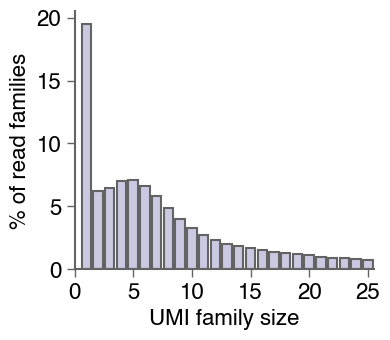

In [12]:
for sample in sorted(mode5_samples)[:1]:
    file = sample_filenames[sample]
    
    fig, ax1 = plt.subplots(1, 1, figsize = (4, 3.5))
    
    x = []
    y = []
    
    with open(file) as txtfile:
        row_count = 0
        reader = csv.reader(txtfile, delimiter = '\t')
        
        for row in reader:
            if row_count>15:
#                 print(row)
                UMI_family_size = int(row[0])
                count = float(row[1])
                fraction = float(row[2])
                reads = UMI_family_size*count 
                x.append(UMI_family_size)
                y.append(fraction*100)
            row_count+=1
            
    ax1.bar(x, y, color = purple2, edgecolor = grey4, lw = 1.5)
    
    ax1.set_xlim(0, 25.5)
    ax1.set_ylim(0, max(y)*1.05)
    
    
    for ax in [ax1]:
#         ax.set_xlim(0, 51)
    #     ax.set_ylim(0, 10)
        ax.set_xlabel('UMI family size', fontsize = 16)
        ax.set_ylabel('% of read families', fontsize = 16)
        ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 16)
        ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
        for axis in ['right', 'top']:
            ax.spines[axis].set_visible(False)
        for axis in ['bottom', 'left']:
            ax.spines[axis].set_linewidth(1.5)
            ax.spines[axis].set_color(grey4)
            
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
            
    
    plt.tight_layout()

    plt.show()

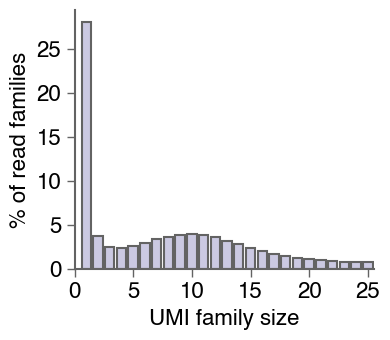

In [13]:
for sample in sorted(mode10_samples)[:1]:
    file = sample_filenames[sample]
    
    fig, ax1 = plt.subplots(1, 1, figsize = (4, 3.5))
    
    x = []
    y = []
    
    with open(file) as txtfile:
        row_count = 0
        reader = csv.reader(txtfile, delimiter = '\t')
        
        for row in reader:
            if row_count>15:
#                 print(row)
                UMI_family_size = int(row[0])
                count = float(row[1])
                fraction = float(row[2])
                reads = UMI_family_size*count 
                x.append(UMI_family_size)
                y.append(fraction*100)
            row_count+=1
            
    ax1.bar(x, y, color = purple2, edgecolor = grey4, lw = 1.5)
    
    ax1.set_xlim(0, 25.5)
    ax1.set_ylim(0, max(y)*1.05)
    
    
    for ax in [ax1]:
#         ax.set_xlim(0, 51)
    #     ax.set_ylim(0, 10)
        ax.set_xlabel('UMI family size', fontsize = 16)
        ax.set_ylabel('% of read families', fontsize = 16)
        ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 16)
        ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
        for axis in ['right', 'top']:
            ax.spines[axis].set_visible(False)
        for axis in ['bottom', 'left']:
            ax.spines[axis].set_linewidth(1.5)
            ax.spines[axis].set_color(grey4)
            
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
            
    
    plt.tight_layout()

    plt.show()

### Supplementary Fig. 7b - Distribution of mean UMI tag family sizes

number of case samples =  249
number of control samples =  247

mean family size cases =  8.025231734998561
max family size cases =  17.19769307562403
min family size cases =  2.397931529638107

mean family size controls =  7.6760590703304175
max family size controls =  17.30579353732013
min family size controls =  2.3898580733231816


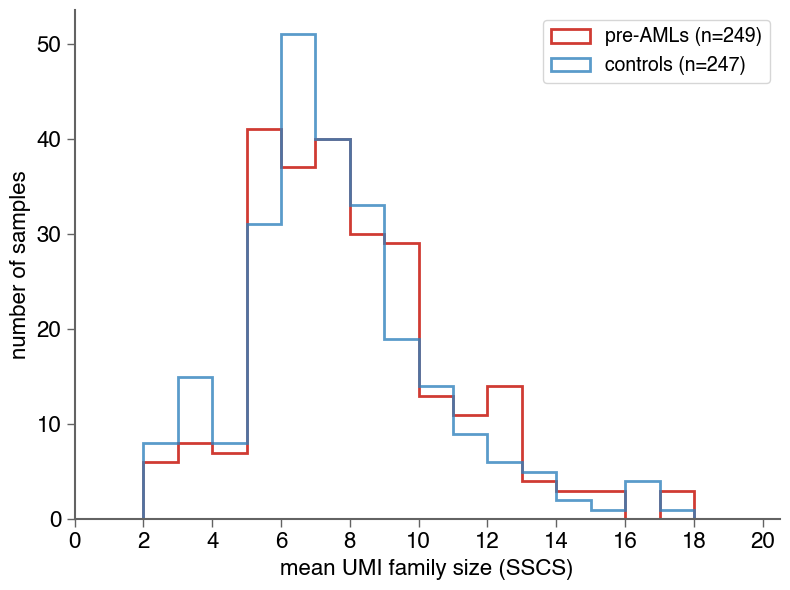

In [14]:
#Mean UMI family size across all samples
fig, ax1 = plt.subplots(1, 1, figsize = (8, 6))

mean_family_sizes_cases = []
mean_family_sizes_controls = []

for k, v in sample_mean_family_size.items():
#     print(k)
    if 'C92' in k:
        mean_family_sizes_cases.append(v[0])
    if 'CNTRL' in k:
        mean_family_sizes_controls.append(v[0])

ax1.hist(mean_family_sizes_cases, bins = 20, range = (0, 20), histtype='step', color = c14, lw = 2, alpha = 0.8, label = 'pre-AMLs (n='+str(len(mean_family_sizes_cases))+')')
ax1.hist(mean_family_sizes_controls, bins = 20, range = (0, 20), histtype='step', color = blue4, lw = 2,  alpha = 0.8, label = 'controls (n='+str(len(mean_family_sizes_controls))+')')

for ax in [ax1]:
    ax.set_xlim(0, 20.5)
#     ax.set_ylim(0, 10)
    ax.set_xlabel('mean UMI family size (SSCS)', fontsize = 16)
    ax.set_ylabel('number of samples', fontsize = 16)
    ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 16)
    ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
    for axis in ['right', 'top']:
        ax.spines[axis].set_visible(False)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey4)
        
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    
ax1.legend(fancybox = True, fontsize = 14)
        
plt.tight_layout()

print('number of case samples = ', len(mean_family_sizes_cases))
print('number of control samples = ', len(mean_family_sizes_controls))
print()
print('mean family size cases = ', np.mean(mean_family_sizes_cases))
print('max family size cases = ', max(mean_family_sizes_cases))
print('min family size cases = ', min(mean_family_sizes_cases))
print()
print('mean family size controls = ', np.mean(mean_family_sizes_controls))
print('max family size controls = ', max(mean_family_sizes_controls))
print('min family size controls = ', min(mean_family_sizes_controls))

### Supplementary Fig. 7b subplot - Standard deviation of mean UMI family sizes

mean std cases =  10.405115646739874
max std cases =  49.50847568655266
min std cases =  2.103045370995785

mean std controls =  9.777493398192677
max std controls =  45.12337090488853
min std controls =  2.049825452562678


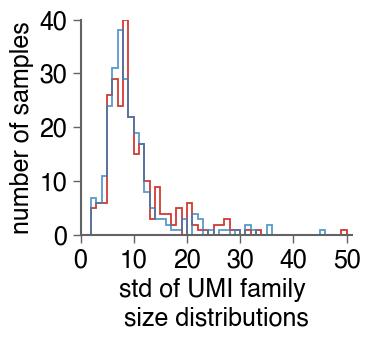

In [15]:
#Mean UMI family size across all samples
fig, ax1 = plt.subplots(1, 1, figsize = (3.8, 3.5))

mean_std_family_sizes_cases = []
mean_std_family_sizes_controls = []

for k, v in sample_mean_family_size.items():
#     print(k)
    if 'C92' in k:
        mean_std_family_sizes_cases.append(v[1])
    if 'CNTRL' in k:
        mean_std_family_sizes_controls.append(v[1])

ax1.hist(mean_std_family_sizes_cases, bins = 51, range = (0, 51), histtype='step', color = c14, lw = 1.3, alpha = 0.8, label = 'pre-AMLs (n='+str(len(mean_std_family_sizes_cases))+')')
ax1.hist(mean_std_family_sizes_controls, bins = 51, range = (0, 51), histtype='step', color = blue4, lw = 1.3,  alpha = 0.8, label = 'controls (n='+str(len(mean_std_family_sizes_controls))+')')

for ax in [ax1]:
    ax.set_xlim(0, 51)
    ax.set_ylim(0, 40)
    ax.set_xlabel('std of UMI family \nsize distributions', fontsize = 18)
    ax.set_ylabel('number of samples', fontsize = 18)
    ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 18)
    ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
    for axis in ['right', 'top']:
        ax.spines[axis].set_visible(False)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey4)
        
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
        
plt.tight_layout()

print('mean std cases = ', np.mean(mean_std_family_sizes_cases))
print('max std cases = ', max(mean_std_family_sizes_cases))
print('min std cases = ', min(mean_std_family_sizes_cases))
print()
print('mean std controls = ', np.mean(mean_std_family_sizes_controls))
print('max std controls = ', max(mean_std_family_sizes_controls))
print('min std controls = ', min(mean_std_family_sizes_controls))

### What is the average maximum UMI family size?

In [16]:
n = 0

all_max_family_sizes = []
max_family_sizes = {}

for k, v in sample_filenames.items():
    sample_name = k
    file = v

    if 'SNV' in os.path.basename(file):
        name = os.path.basename(file).split('SNV')[0][:-1]
    else:
        name = os.path.basename(file).split('watson')[0][:-1]

    UMI_family_sizes = {}
    total_reads = 0
    total_count = 0

    m = 0
    
    family_sizes = []
    
    #calculate mode
    with open(file) as txtfile:
        row_count = 0
        reader = csv.reader(txtfile, delimiter = '\t')
        for row in reader:
            if row_count>15:
#                 print(row)
                UMI_family_size = int(row[0])
                count = float(row[1])
                fraction = row[2]
                reads = UMI_family_size*count 
                total_reads += reads
                total_count += count
                family_sizes.append(int(UMI_family_size))
            row_count+=1

        max_UMI_family_size = max(family_sizes)

        max_family_sizes[k]=max_UMI_family_size
        all_max_family_sizes.append(max_UMI_family_size)

np.mean(all_max_family_sizes)

np.float64(175.3125)

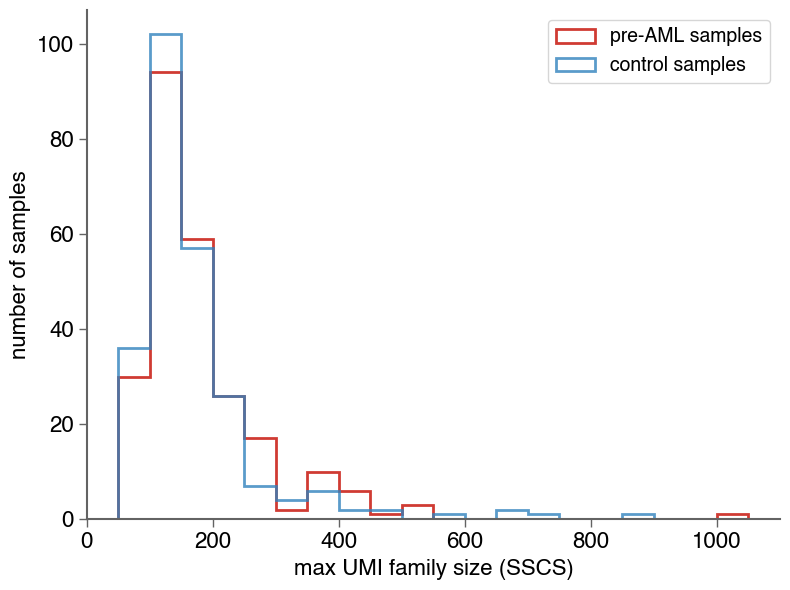

In [17]:
#Max UMI family size across all samples
fig, ax1 = plt.subplots(1, 1, figsize = (8, 6))

max_family_sizes_cases = []
max_family_sizes_controls = []

for k, v in max_family_sizes.items():
#     print(k)
    if 'C92' in k:
        max_family_sizes_cases.append(float(v))
    if 'CNTRL' in k:
        max_family_sizes_controls.append(float(v))
               
ax1.hist(max_family_sizes_cases, histtype='step', bins = 22, range = (0, 1100), color = c14, lw = 2, alpha = 0.8, label = 'pre-AML samples')
ax1.hist(max_family_sizes_controls, histtype='step', bins = 22, range = (0, 1100), color = blue4, lw = 2,  alpha = 0.8, label = 'control samples')

for ax in [ax1]:
    ax.set_xlim(0, 1100)
#     ax.set_ylim(0, 10)
    ax.set_xlabel('max UMI family size (SSCS)', fontsize = 16)
    ax.set_ylabel('number of samples', fontsize = 16)
    ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 16)
    ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
    for axis in ['right', 'top']:
        ax.spines[axis].set_visible(False)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey4)
        
#     ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    
ax1.legend(fancybox = True, fontsize = 14)


        
plt.tight_layout()

### Supplementary Fig 7c - distribution of proportion of total reads retained if UMI families of size <3 are excluded

In [18]:
#Proportion of reads retained with minimum UMI family size of 3
n = 0

retained_reads = {}
total_reads_per_sample = {}

for k, v in sample_filenames.items():
    sample_name = k
    file = v

    if 'SNV' in os.path.basename(file):
        name = os.path.basename(file).split('SNV')[0][:-1]
    else:
        name = os.path.basename(file).split('watson')[0][:-1]

    UMI_family_sizes = {}
    total_reads = 0
    total_count = 0

    m = 0
    
    one_or_two_family_size = 0
    three_or_more_family_size = 0
    three_or_more_family_size_reads = 0
    
    #calculate mode
    with open(file) as txtfile:
        row_count = 0
        reader = csv.reader(txtfile, delimiter = '\t')
        for row in reader:
            if row_count>15:
#                 print(row)
                UMI_family_size = int(row[0])
                count = float(row[1])
                fraction = row[2]
                reads = UMI_family_size*count 
                
                if UMI_family_size <3:
                    one_or_two_family_size+=count
                else:
                    three_or_more_family_size+=count
                    
                if UMI_family_size >=3:
                    three_or_more_family_size_reads+=(UMI_family_size*count)
                    
                total_reads += reads
                total_count += count
                
            row_count+=1
            
        total_reads_per_sample[sample_name]=total_reads
            
        proportion_unique_retained = three_or_more_family_size/total_count
        proportion_reads_retained = three_or_more_family_size_reads/total_reads
        
        retained_reads[name]=(proportion_unique_retained, proportion_reads_retained)

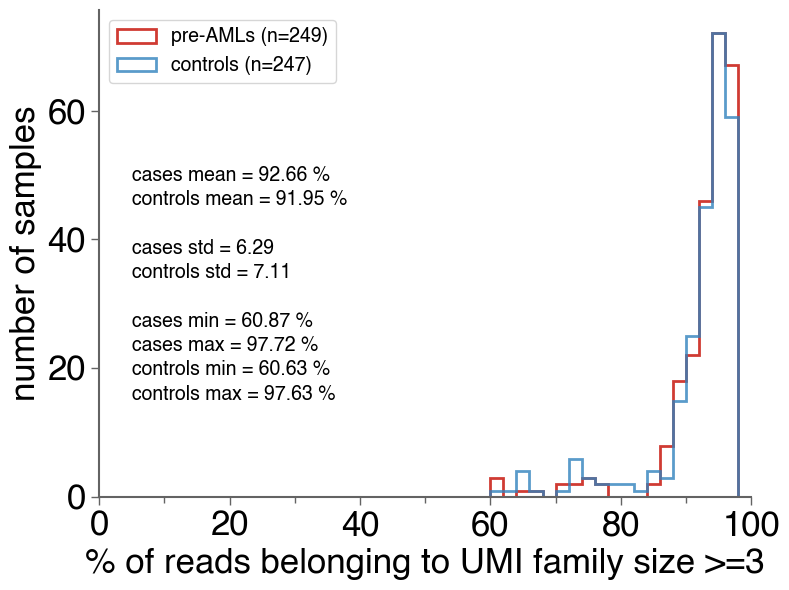

In [19]:
#% of reads retained if minimum UMI family size of 3
fig, ax1 = plt.subplots(1, 1, figsize = (8, 6))

retained_reads_cases = []
retained_reads_controls = []

retained_unique_molecules_cases = []
retained_unique_molecules_controls = []

for k, v in retained_reads.items():
#     print(k)
    if 'C92' in k:
        retained_unique_molecules_cases.append(v[0]*100)
        retained_reads_cases.append(v[1]*100)
    if 'CNTRL' in k:
        retained_unique_molecules_controls.append(v[0]*100)
        retained_reads_controls.append(v[1]*100)

ax1.hist(retained_reads_cases, bins = 50, range = (0, 100), histtype='step', color = c14, lw = 2, alpha = 0.8, label = 'pre-AMLs (n='+str(len(retained_reads_cases))+')')
ax1.hist(retained_reads_controls, bins = 50, range = (0, 100), histtype='step', color = blue4, lw = 2,  alpha = 0.8, label = 'controls (n='+str(len(retained_reads_controls))+')')

for ax in [ax1]:
    ax.set_xlim(0, 100)
#     ax.set_ylim(0, 10)
    ax.set_xlabel('% of reads belonging to UMI family size >=3', fontsize = 25)
    ax.set_ylabel('number of samples', fontsize = 25)
    ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 25)
    ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
    for axis in ['right', 'top']:
        ax.spines[axis].set_visible(False)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey4)
        
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    
ax1.legend(fancybox = True, fontsize = 14, loc = 'upper left')

ax1.text(0.05, 0.65, 'cases mean = '+str(round(np.mean(retained_reads_cases), 2))+' %', transform=ax1.transAxes, ha = 'left', fontsize = 14)
ax1.text(0.05, 0.6, 'controls mean = '+str(round(np.mean(retained_reads_controls), 2))+' %', transform=ax1.transAxes, ha = 'left', fontsize = 14)

ax1.text(0.05, 0.5, 'cases std = '+str(round(np.std(retained_reads_cases), 2)), transform=ax1.transAxes, ha = 'left', fontsize = 14)
ax1.text(0.05, 0.45, 'controls std = '+str(round(np.std(retained_reads_controls), 2)), transform=ax1.transAxes, ha = 'left', fontsize = 14)

ax1.text(0.05, 0.35, 'cases min = '+str(round(min(retained_reads_cases), 2))+' %', transform=ax1.transAxes, ha = 'left', fontsize = 14)
ax1.text(0.05, 0.3, 'cases max = '+str(round(max(retained_reads_cases), 2))+' %', transform=ax1.transAxes, ha = 'left', fontsize = 14)
ax1.text(0.05, 0.25, 'controls min = '+str(round(min(retained_reads_controls), 2))+' %', transform=ax1.transAxes, ha = 'left', fontsize = 14)
ax1.text(0.05, 0.2, 'controls max = '+str(round(max(retained_reads_controls), 2))+' %', transform=ax1.transAxes, ha = 'left', fontsize = 14)
        
plt.tight_layout()

### Supplementary Fig 7d -  distribution of proportion of UMI families retained if those containing <3 reads are discarded

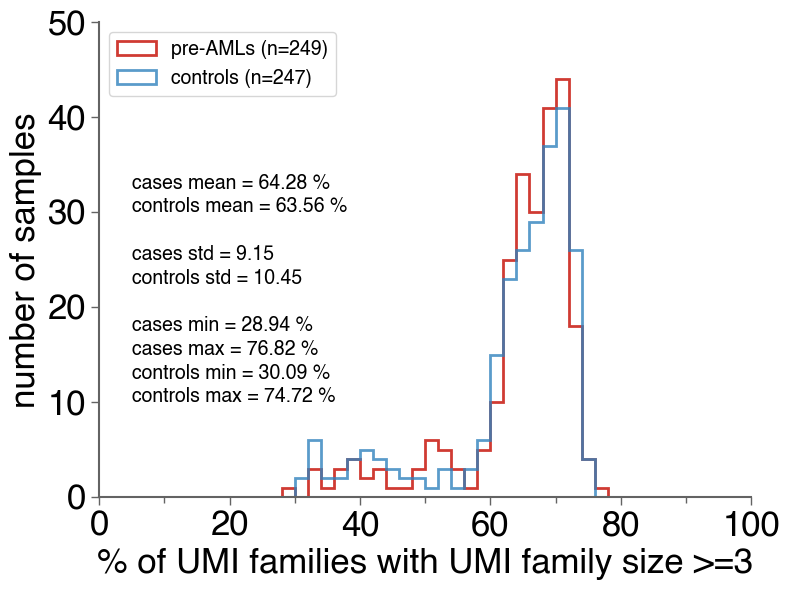

In [20]:
#% of unique molecules retained if minimum UMI family size 3
fig, ax1 = plt.subplots(1, 1, figsize = (8, 6))

retained_reads_cases = []
retained_reads_controls = []

retained_unique_molecules_cases = []
retained_unique_molecules_controls = []

for k, v in retained_reads.items():
#     print(k)
    if 'C92' in k:
        retained_unique_molecules_cases.append(v[0]*100)
        retained_reads_cases.append(v[1]*100)
    if 'CNTRL' in k:
        retained_unique_molecules_controls.append(v[0]*100)
        retained_reads_controls.append(v[1]*100)

ax1.hist(retained_unique_molecules_cases, bins = 50, range = (0, 100), histtype='step', color = c14, lw = 2, alpha = 0.8, label = 'pre-AMLs (n='+str(len(retained_unique_molecules_cases))+')')
ax1.hist(retained_unique_molecules_controls, bins = 50, range = (0, 100), histtype='step', color = blue4, lw = 2,  alpha = 0.8, label = 'controls (n='+str(len(retained_unique_molecules_controls))+')')

for ax in [ax1]:
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 50)
    ax.set_xlabel('% of UMI families with UMI family size >=3', fontsize = 25)
    ax.set_ylabel('number of samples', fontsize = 25)
    ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 25)
    ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
    for axis in ['right', 'top']:
        ax.spines[axis].set_visible(False)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey4)
        
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    
ax1.legend(fancybox = True, fontsize = 14, loc = 'upper left')

ax1.text(0.05, 0.65, 'cases mean = '+str(round(np.mean(retained_unique_molecules_cases), 2))+' %', transform=ax1.transAxes, ha = 'left', fontsize = 14)
ax1.text(0.05, 0.6, 'controls mean = '+str(round(np.mean(retained_unique_molecules_controls), 2))+' %', transform=ax1.transAxes, ha = 'left', fontsize = 14)

ax1.text(0.05, 0.5, 'cases std = '+str(round(np.std(retained_unique_molecules_cases), 2)), transform=ax1.transAxes, ha = 'left', fontsize = 14)
ax1.text(0.05, 0.45, 'controls std = '+str(round(np.std(retained_unique_molecules_controls), 2)), transform=ax1.transAxes, ha = 'left', fontsize = 14)

ax1.text(0.05, 0.35, 'cases min = '+str(round(min(retained_unique_molecules_cases), 2))+' %', transform=ax1.transAxes, ha = 'left', fontsize = 14)
ax1.text(0.05, 0.3, 'cases max = '+str(round(max(retained_unique_molecules_cases), 2))+' %', transform=ax1.transAxes, ha = 'left', fontsize = 14)
ax1.text(0.05, 0.25, 'controls min = '+str(round(min(retained_unique_molecules_controls), 2))+' %', transform=ax1.transAxes, ha = 'left', fontsize = 14)
ax1.text(0.05, 0.2, 'controls max = '+str(round(max(retained_unique_molecules_controls), 2))+' %', transform=ax1.transAxes, ha = 'left', fontsize = 14)
        
plt.tight_layout()

### Supplementary Fig 7e - SSCS to DCS ratio

In [21]:
#Filenames for each timepoint for each sample (sampleS)...
n = 0
DCS_sample_filenames = {}
timepoints_available = {}
cases = []
controls = []

for sample in cases_and_controls_sorted.keys():
    filenames = []
    timepoints = cases_and_controls_sorted[sample]
    for time in timepoints:
        for library in libraries:
            filename = 'Data_files/Supp Fig. 7 - Error corrected sequencing metrics/SSCS_to_DCS_ratio_metrics/'+library+'/'+time+'_SNV_watson_code_DCS_metrics.txt'
            filename2 = 'Data_files/Supp Fig. 7 - Error corrected sequencing metrics/SSCS_to_DCS_ratio_metrics/'+library+'/'+time+'_watson_code_DCS_metrics.txt'
            if os.path.isfile(filename):
                DCS_sample_filenames[time]=filename
                if 'C92' in sample:
                    if sample not in cases:
                        cases.append(sample)
                else:
                    if sample not in controls:
                        controls.append(sample)
            if os.path.isfile(filename2):
                DCS_sample_filenames[time]=filename2
                if 'C92' in sample:
                    if sample not in cases:
                        cases.append(sample)
                else:
                    if sample not in controls:
                        controls.append(sample)

    n+=1

DCS_sample_filenames


cases = 0
controls = 0
for k, v in DCS_sample_filenames.items():
    if k[:3] == 'C92':
        cases+=1
    else:
        controls+=1


In [22]:
n = 0
SSCS_to_DCS_ratio = {}

for k, v in DCS_sample_filenames.items():
    sample_name = k
    file = v

    if 'SNV' in os.path.basename(file):
        name = os.path.basename(file).split('SNV')[0][:-1]
    else:
        name = os.path.basename(file).split('watson')[0][:-1]

    UMI_family_sizes = {}
    total_reads = 0
    total_count = 0

    m = 0

    with open(file) as txtfile:
        row_count = 0
        reader = csv.reader(txtfile, delimiter = '\t')
        for row in reader:
            if row_count==7:
                total_SSSCS_included_in_consensus_calling = int(row[1])
            if row_count==8:
                total_SSCS_without_duplex_partner = int(row[1])
            if row_count==10:
                total_DCS_created = int(row[1]) #read 1 and read 2 separate
            if row_count == 13:
                total_unpartnered_DCS = int(row[1])
#                 print(total_unpartnered_DCS)
            if row_count == 14:
                SSCS_DCS_ratio = float(row[1])

            row_count+=1

        SSCS_to_DCS_ratio[sample_name]=SSCS_DCS_ratio
                              

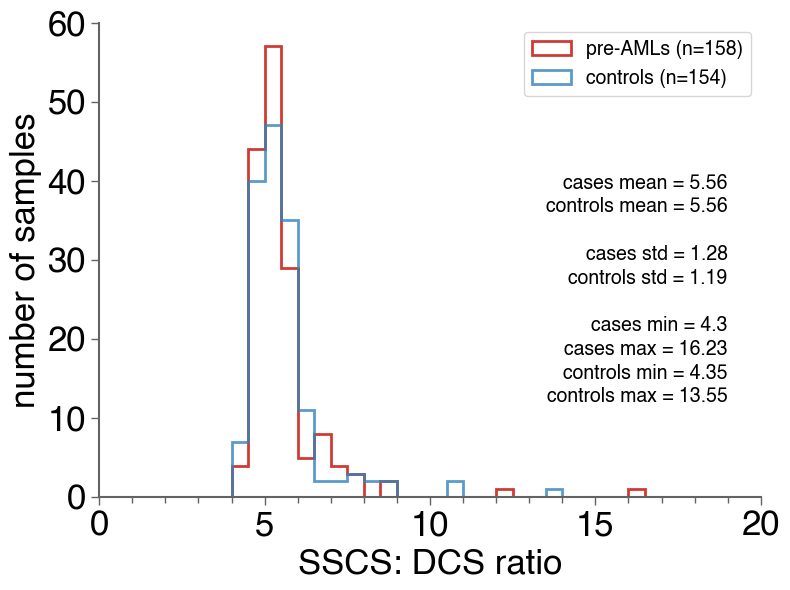

In [23]:
fig, ax1 = plt.subplots(1, 1, figsize = (8, 6))

SSCS_DCS_cases = []
SSCS_DCS_controls = []

for k, v in SSCS_to_DCS_ratio.items():
#     print(k)
    if 'C92' in k:
        SSCS_DCS_cases.append(v)
    if 'CNTRL' in k:
        SSCS_DCS_controls.append(v)
        
ax1.hist(SSCS_DCS_cases, histtype='step', bins = 40, range = (0, 20), color = c14, lw = 2, alpha = 0.8, label = 'pre-AMLs (n='+str(len(SSCS_DCS_cases))+')')
ax1.hist(SSCS_DCS_controls, histtype='step', bins = 40, range = (0, 20),color = blue4, lw = 2,  alpha = 0.8, label = 'controls (n='+str(len(SSCS_DCS_controls))+')')

for ax in [ax1]:
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 60)
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    
    ax.set_xlabel('SSCS: DCS ratio', fontsize = 25)
    ax.set_ylabel('number of samples', fontsize = 25)
    ax.tick_params(axis = 'both', which = 'both', color = grey4, length = 6, width = 1, labelsize = 25)
    ax.tick_params(axis = 'both', which='minor', color = grey4, bottom=True, width = 1, length = 4)
    for axis in ['right', 'top']:
        ax.spines[axis].set_visible(False)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey4)
    
ax1.legend(fancybox = True, fontsize = 14, loc = 'upper right')

ax1.text(0.95, 0.65, 'cases mean = '+str(round(np.mean(SSCS_DCS_cases), 2)), transform=ax1.transAxes, ha = 'right', fontsize = 14)
ax1.text(0.95, 0.6, 'controls mean = '+str(round(np.mean(SSCS_DCS_controls), 2)), transform=ax1.transAxes, ha = 'right', fontsize = 14)

ax1.text(0.95, 0.5, 'cases std = '+str(round(np.std(SSCS_DCS_cases), 2)), transform=ax1.transAxes, ha = 'right', fontsize = 14)
ax1.text(0.95, 0.45, 'controls std = '+str(round(np.std(SSCS_DCS_controls), 2)), transform=ax1.transAxes, ha = 'right', fontsize = 14)

ax1.text(0.95, 0.35, 'cases min = '+str(round(min(SSCS_DCS_cases), 2)), transform=ax1.transAxes, ha = 'right', fontsize = 14)
ax1.text(0.95, 0.3, 'cases max = '+str(round(max(SSCS_DCS_cases), 2)), transform=ax1.transAxes, ha = 'right', fontsize = 14)
ax1.text(0.95, 0.25, 'controls min = '+str(round(min(SSCS_DCS_controls), 2)), transform=ax1.transAxes, ha = 'right', fontsize = 14)
ax1.text(0.95, 0.2, 'controls max = '+str(round(max(SSCS_DCS_controls), 2)), transform=ax1.transAxes, ha = 'right', fontsize = 14)
        
plt.tight_layout()